In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [2]:
band2_path = r"C:\Users\suyas\Desktop\JupyterLab-setup\Bootcamp\assignment\221666051\BAND2.tif"
band3_path = r"C:\Users\suyas\Desktop\JupyterLab-setup\Bootcamp\assignment\221666051\BAND3.tif"
band4_path = r"C:\Users\suyas\Desktop\JupyterLab-setup\Bootcamp\assignment\221666051\BAND4.tif"

crop_window = Window(1500, 1500, 800, 800)

In [3]:
with rasterio.open(band2_path) as b2, \
     rasterio.open(band3_path) as b3, \
     rasterio.open(band4_path) as b4:

    b2_data = b2.read(1, window=crop_window).astype(np.float32)
    b3_data = b3.read(1, window=crop_window).astype(np.float32)
    b4_data = b4.read(1, window=crop_window).astype(np.float32)

print("Grid shape:", b2_data.shape)

Grid shape: (800, 800)


In [4]:
ndwi_data = (b2_data - b4_data) / (b2_data + b4_data + 1e-10)

labels_data = np.where(ndwi_data > 0.3, 1, 0)

In [5]:
df = pd.DataFrame({
    "Green": b2_data.flatten(),
    "Red": b3_data.flatten(),
    "NIR": b4_data.flatten(),
    "NDWI": ndwi_data.flatten(),
    "Label": labels_data.flatten()
})

X = df[["Green", "Red", "NIR", "NDWI"]]
y = df["Label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
model = RandomForestClassifier(
    n_estimators=30,
    max_depth=8,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total num

In [8]:
y_pred = model.predict(X_test)

print("Model Evaluation:")
print(classification_report(y_test, y_pred))

Model Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    191444
           1       1.00      1.00      1.00       556

    accuracy                           1.00    192000
   macro avg       1.00      1.00      1.00    192000
weighted avg       1.00      1.00      1.00    192000



In [9]:
predictions = model.predict(X)
predicted_map = predictions.reshape(b2_data.shape)

In [10]:
def normalize(band):
    return (band - band.min()) / (band.max() - band.min() + 1e-10)

fcc = np.dstack((
    normalize(b4_data),
    normalize(b3_data),
    normalize(b2_data)
))

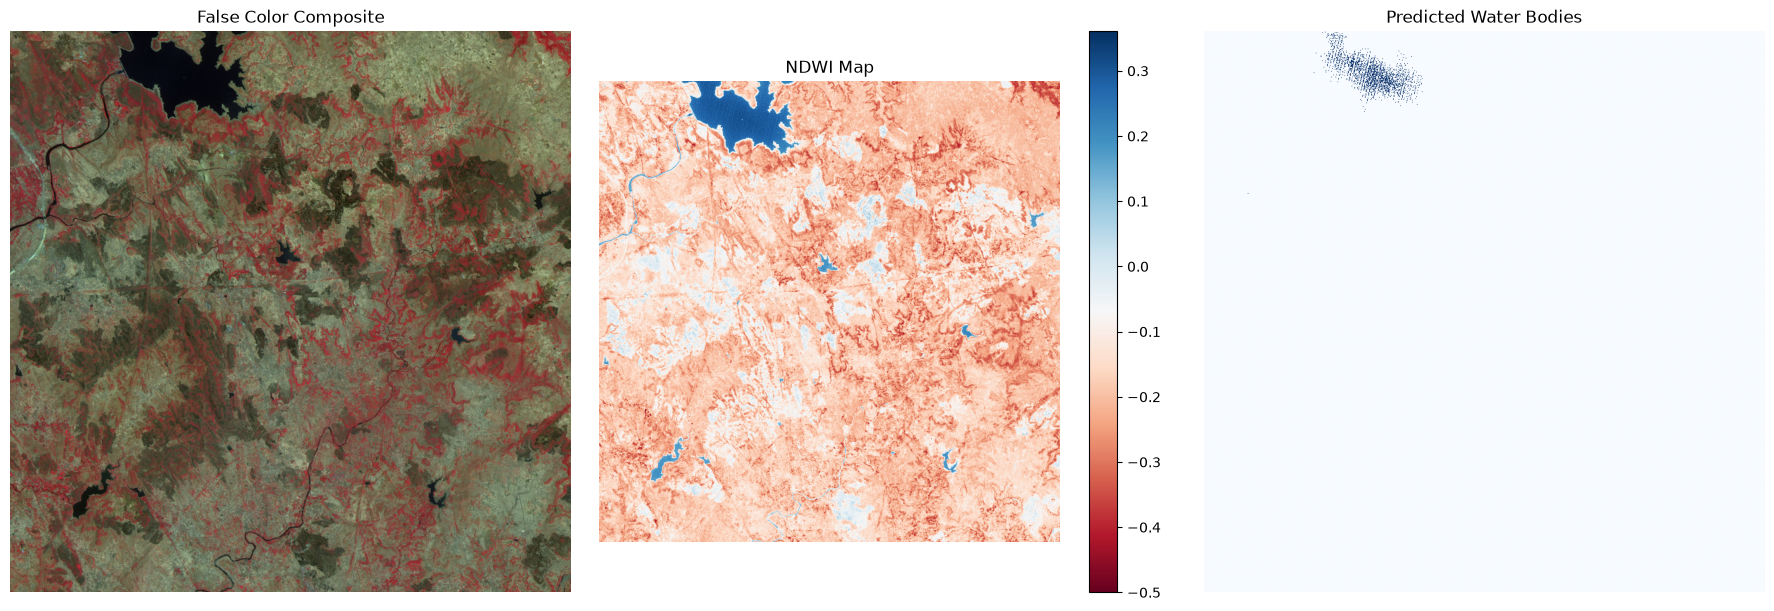

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(fcc)
axes[0].set_title("False Color Composite")
axes[0].axis("off")

im = axes[1].imshow(ndwi_data, cmap="RdBu")
axes[1].set_title("NDWI Map")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1])

axes[2].imshow(predicted_map, cmap="Blues")
axes[2].set_title("Predicted Water Bodies")
axes[2].axis("off")

plt.tight_layout()
plt.show()